In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Check available files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', 
                 encoding='latin-1')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


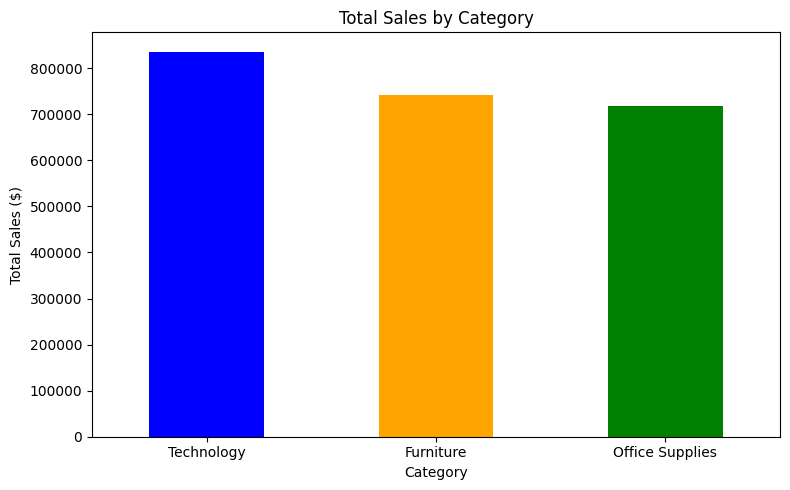

Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [3]:
# ANALYSIS 1 — Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color=['blue','orange','green'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Sales by Category:")
print(category_sales)

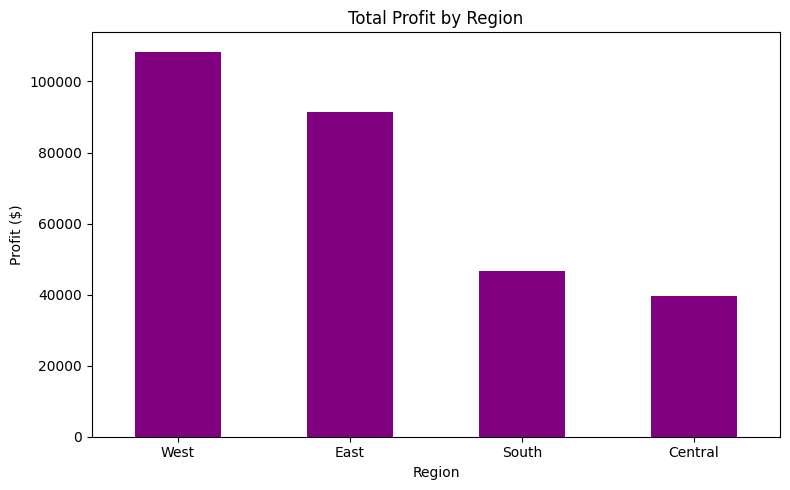

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [4]:
# ANALYSIS 2 — Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar', color='purple')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(region_profit)

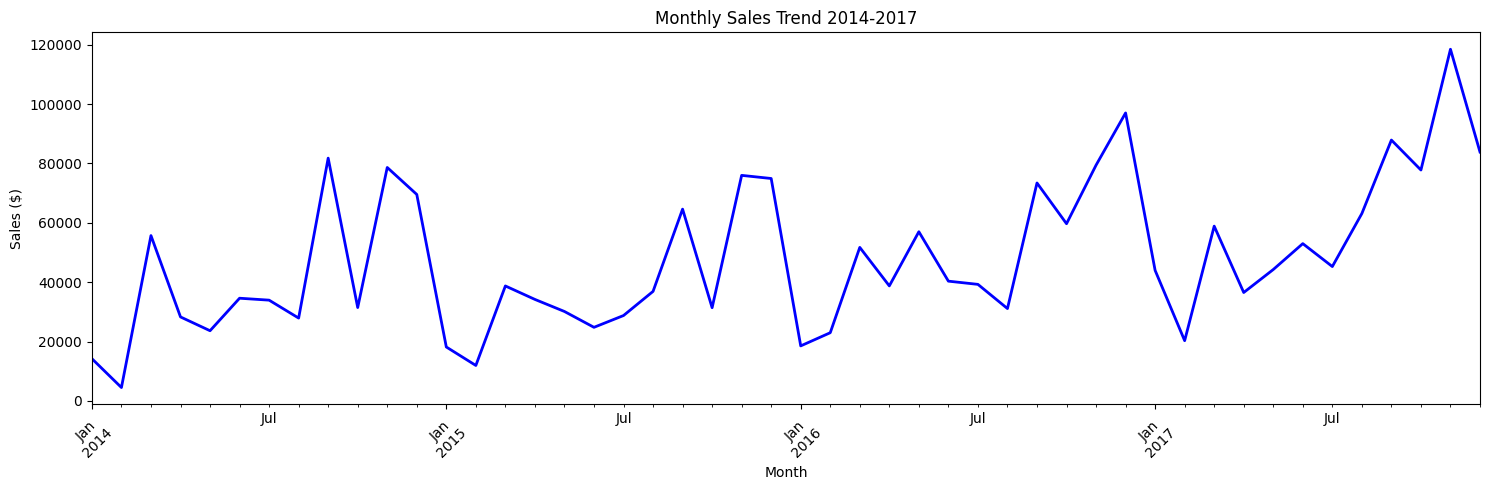

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month_Year'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(15,5))
monthly_sales.plot(kind='line', color='blue', linewidth=2)
plt.title('Monthly Sales Trend 2014-2017')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

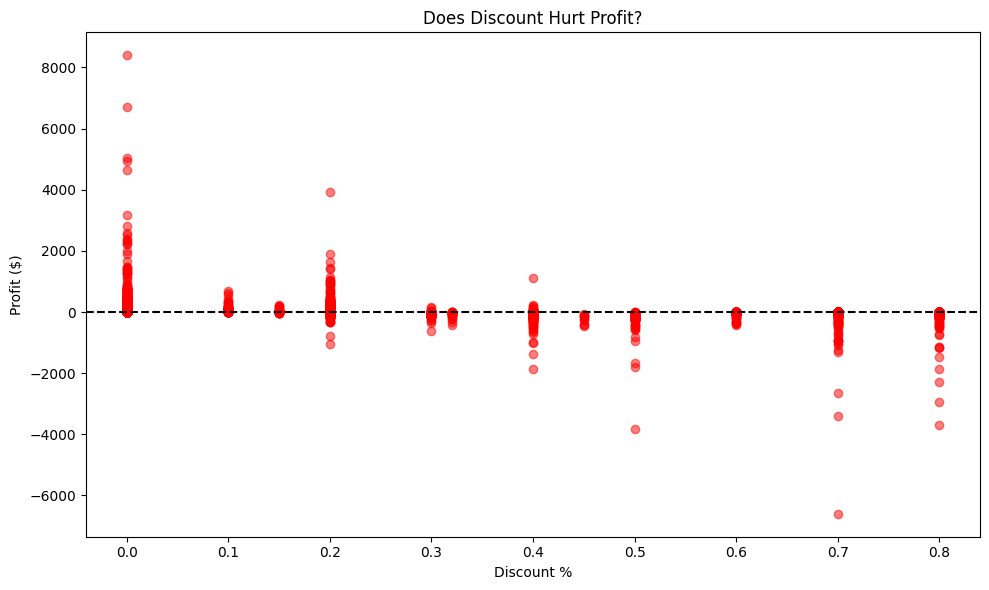

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5, color='red')
plt.title('Does Discount Hurt Profit?')
plt.xlabel('Discount %')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [7]:
print("=" * 50)
print("KEY BUSINESS INSIGHTS")
print("=" * 50)
print(f"Total Revenue: ${df['Sales'].sum():,.0f}")
print(f"Total Profit: ${df['Profit'].sum():,.0f}")
print(f"Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.1f}%")
print(f"Total Orders: {df['Order ID'].nunique()}")
print(f"Total Customers: {df['Customer ID'].nunique()}")
print(f"Best Region: {df.groupby('Region')['Profit'].sum().idxmax()}")
print(f"Worst Region: {df.groupby('Region')['Profit'].sum().idxmin()}")
print(f"Best Sub-Category: {df.groupby('Sub-Category')['Profit'].sum().idxmax()}")
print(f"Worst Sub-Category: {df.groupby('Sub-Category')['Profit'].sum().idxmin()}")

KEY BUSINESS INSIGHTS
Total Revenue: $2,297,201
Total Profit: $286,397
Profit Margin: 12.5%
Total Orders: 5009
Total Customers: 793
Best Region: West
Worst Region: Central
Best Sub-Category: Copiers
Worst Sub-Category: Tables
